In [1]:
import pandas as pd
import numpy as np
import re
import string

# NLP
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Twitter_Data.csv')

print(df.head())
print(df.info())

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB
None


In [5]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"\d+", "", text)            # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

df['cleaned_text'] = df['clean_text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SAMIKSHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df.dropna(inplace=True)

In [7]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text'])
y = df['category']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [10]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [11]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nSVM Classification Report:\n")
print(classification_report(y_test, svm_pred))

Naive Bayes Accuracy: 0.7263606798797325
SVM Accuracy: 0.9022519482113273

SVM Classification Report:

              precision    recall  f1-score   support

        -1.0       0.88      0.81      0.85      7152
         0.0       0.88      0.97      0.92     11067
         1.0       0.93      0.89      0.91     14375

    accuracy                           0.90     32594
   macro avg       0.90      0.89      0.89     32594
weighted avg       0.90      0.90      0.90     32594



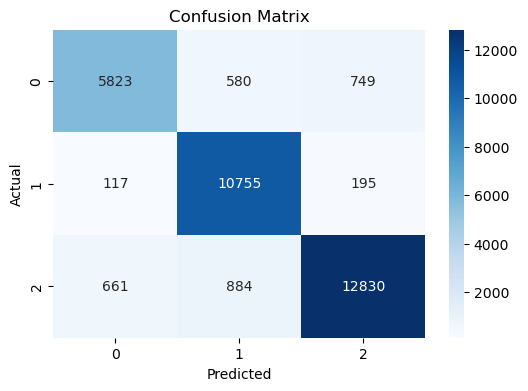

In [12]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

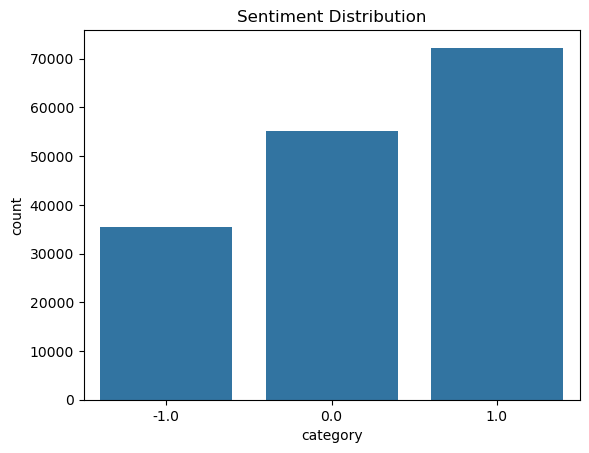

In [13]:
sns.countplot(x='category', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [14]:
df.to_csv('cleaned_twitter_data.csv', index=False)